# From association to TMLE with the TWINS data

This notebook follows one question from an observed association through identification and estimation. It compares g-computation, IPW, manual targeting, and cross-validated TMLE. It then tests how design and assumptions affect the answer.

The target is deliberately **illustrative**, not a clinical claim. Low birth weight is a state produced by many processes, not one well-defined treatment. A causal reading would require a coherent intervention that sets birth-weight status without changing mortality through unspecified side effects, plus consistency across versions of that intervention. The public data also omit plausible common causes.

The notebook defines the estimand and identification assumptions. It shows what targeting changes and what diagnostics can observe. See the [collaborative TMLE](../technical-reference/collaborative-tmle.md) and [DR-TMLE](../technical-reference/dr-tmle/index.md) entries for advanced variants.

## 1. Setup and reproducibility

Run from the project environment. The three source URLs are pinned to one CEVAE commit, and pairs rather than individual children are sampled so both twins remain together.

In [1]:
import platform
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

import cleverly
from cleverly import (
    ATE,
    CausalStudy,
    CounterfactualMean,
    CrossFitting,
    Inference,
    LongitudinalTreatment,
    ModelSpec,
    PointTreatment,
    RegimeContrast,
    Runtime,
    SuperLearner,
    TMLEMethod,
)

SEED = 2026
N_PAIRS = 6_000
pd.set_option("display.max_columns", 20)
pd.set_option("display.precision", 4)
warnings.filterwarnings("ignore", category=UserWarning)

## 2. Load pairs and encode covariates honestly

The [CEVAE TWINS README](https://github.com/AMLab-Amsterdam/CEVAE/blob/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS/ReadmeTwins) describes same-sex US twin pairs born in 1989–1991, with birth weight and three-year mortality recorded for both children. Twin 0 is the lighter twin and twin 1 the heavier twin.

The source [covariate metadata](https://github.com/AMLab-Amsterdam/CEVAE/blob/9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd/datasets/TWINS/covar_type.txt) labels maternal age, education, race, region, and year as categorical. Their integer codes are labels, not equally spaced measurements, so we one-hot encode them. Binary missing values receive a fixed fill value plus an explicit indicator; identical missingness patterns share one indicator so the design contains no duplicate columns.

In [2]:
COMMIT = "9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd"
BASE_URL = f"https://raw.githubusercontent.com/AMLab-Amsterdam/CEVAE/{COMMIT}/datasets/TWINS"
FILES = {
    "X": "twin_pairs_X_3years_samesex.csv",
    "T": "twin_pairs_T_3years_samesex.csv",
    "Y": "twin_pairs_Y_3years_samesex.csv",
}
raw = {name: pd.read_csv(f"{BASE_URL}/{filename}") for name, filename in FILES.items()}
assert raw["X"].shape[0] == raw["T"].shape[0] == raw["Y"].shape[0]

pair_rows = raw["X"].sample(n=N_PAIRS, random_state=SEED).index.sort_values().to_numpy()
X = raw["X"].loc[pair_rows].reset_index(drop=True)
T = raw["T"].loc[pair_rows].reset_index(drop=True)
Y = raw["Y"].loc[pair_rows].reset_index(drop=True)

shared = [
    "mager8",
    "meduc6",
    "mrace",
    "dmar",
    "mplbir_reg",
    "data_year",
    "diabetes",
    "chyper",
    "phyper",
    "preterm",
    "tobacco",
    "alcohol",
]
children = []
for twin in (0, 1):
    child = X[shared].copy()
    child["pair_id"] = np.arange(N_PAIRS)
    child["twin"] = twin
    child["birth_order"] = X[f"bord_{twin}"]
    child["birth_weight_g"] = T[f"dbirwt_{twin}"]
    child["mortality_3y"] = Y[f"mort_{twin}"].astype(int)
    children.append(child)

twins = (
    pd.concat(children, ignore_index=True).sort_values(["pair_id", "twin"]).reset_index(drop=True)
)
twins["low_birth_weight"] = (twins["birth_weight_g"] < 2_500).astype(int)

CATEGORICAL = ["mager8", "meduc6", "mrace", "mplbir_reg", "data_year"]
BINARY = [
    "dmar",
    "diabetes",
    "chyper",
    "phyper",
    "preterm",
    "tobacco",
    "alcohol",
    "birth_order",
]
point_data = twins.copy()
adjustment = []
missing_patterns = set()
for column in BINARY:
    missing = point_data[column].isna()
    signature = missing.to_numpy().tobytes()
    if missing.any() and signature not in missing_patterns:
        indicator = f"{column}_missing"
        point_data[indicator] = missing.astype(float)
        adjustment.append(indicator)
        missing_patterns.add(signature)
    point_data[column] = point_data[column].fillna(0).astype(float)
    adjustment.append(column)

encoded = pd.get_dummies(
    point_data[CATEGORICAL].fillna(-1).astype("category"),
    prefix=CATEGORICAL,
    dtype=float,
)
point_data = pd.concat([point_data, encoded], axis=1)
adjustment.extend(encoded.columns.tolist())
ADJUSTMENT = tuple(adjustment)

pd.Series(
    {
        "children": len(point_data),
        "pairs": point_data["pair_id"].nunique(),
        "encoded adjustment columns": len(ADJUSTMENT),
        "low birth weight prevalence": point_data["low_birth_weight"].mean(),
        "three-year mortality": point_data["mortality_3y"].mean(),
    },
    name="value",
)

children                       12000.0000
pairs                           6000.0000
encoded adjustment columns        49.0000
low birth weight prevalence        0.5145
three-year mortality               0.0359
Name: value, dtype: float64

## 3. Association first, then a design stress test

Let A indicate birth weight below 2,500 g and Y indicate mortality by age three. The crude difference E(Y | A=1) − E(Y | A=0) is descriptive.

Twins also offer a simple stress test: within pairs where one child falls below the threshold and the other does not, compare their outcomes. This controls factors shared by the pair, but it targets only threshold-discordant pairs, retains child-specific confounding, and can be affected by interference. It is therefore **not** a replacement ATE or a causal truth. A large disagreement is evidence that design choices matter.

In [3]:
observed_risks = point_data.groupby("low_birth_weight")["mortality_3y"].mean()
crude_rd = observed_risks.loc[1] - observed_risks.loc[0]

discordant_ids = (
    point_data.groupby("pair_id")["low_birth_weight"].nunique().loc[lambda value: value == 2].index
)
discordant = point_data[point_data["pair_id"].isin(discordant_ids)]
paired_outcomes = discordant.pivot(
    index="pair_id", columns="low_birth_weight", values="mortality_3y"
)
paired_differences = (paired_outcomes[1] - paired_outcomes[0]).to_numpy(float)
paired_rd = paired_differences.mean()
rng = np.random.default_rng(SEED)
paired_bootstrap = rng.choice(
    paired_differences, size=(20_000, len(paired_differences)), replace=True
).mean(axis=1)
paired_ci = np.quantile(paired_bootstrap, [0.025, 0.975])

assert len(paired_differences) == 1_290
assert paired_rd == np.mean(paired_differences)

pd.DataFrame(
    [
        {
            "contrast": "all children: crude association",
            "estimate": crude_rd,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "population": "sampled children",
        },
        {
            "contrast": "within threshold-discordant pairs",
            "estimate": paired_rd,
            "ci_low": paired_ci[0],
            "ci_high": paired_ci[1],
            "population": f"{len(paired_differences):,} discordant pairs",
        },
    ]
)

,contrast,estimate,ci_low,ci_high,population
0,all children: crude association,0.0615,NaN,NaN,sampled children
1,within threshold-discordant pairs,0.0085,0.0008,0.0171,"1,290 discordant pairs"


The crude difference is 0.0615; the within-pair difference is about 0.0085 with a paired bootstrap interval of roughly [0.0008, 0.0171]. The estimates are not directly interchangeable, but a sevenfold gap is a warning against treating covariate adjustment as a formality. It is stronger evidence about design sensitivity than agreement among several estimators that all use the same adjustment set.

## 4. State the causal target before fitting

The illustrative target is the population ATE, E(Y¹) − E(Y⁰). Identification by the g-formula additionally requires consistency for the intervention being imagined, conditional exchangeability given the encoded adjustment set, and positivity. Pair clustering changes folds and uncertainty; it does not remove confounding.

In [4]:
point_study = CausalStudy(
    point_data,
    design=PointTreatment(
        outcome="mortality_3y",
        treatment="low_birth_weight",
        adjustment=ADJUSTMENT,
        cluster="pair_id",
        outcome_family="binomial",
    ),
)
ate_effect = point_study.identify(ATE(reference=0))
print(ate_effect.summary())

average treatment effect, E[Y^a] - E[Y^reference]
identified by explicit-adjustment: E_W[E(Y | A=a, W)] and the declared smooth contrast
adjustment/history: ['dmar', 'diabetes_missing', 'diabetes', 'chyper', 'phyper', 'preterm_missing', 'preterm', 'tobacco_missing', 'tobacco', 'alcohol_missing', 'alcohol', 'birth_order_missing', 'birth_order', 'mager8_1', 'mager8_2', 'mager8_3', 'mager8_4', 'mager8_5', 'mager8_6', 'mager8_7', 'mager8_8', 'meduc6_-1.0', 'meduc6_1.0', 'meduc6_2.0', 'meduc6_3.0', 'meduc6_4.0', 'meduc6_5.0', 'mrace_1', 'mrace_2', 'mrace_3', 'mrace_4', 'mrace_5', 'mrace_6', 'mrace_7', 'mrace_8', 'mrace_9', 'mplbir_reg_-1.0', 'mplbir_reg_0.0', 'mplbir_reg_1.0', 'mplbir_reg_2.0', 'mplbir_reg_3.0', 'mplbir_reg_4.0', 'mplbir_reg_5.0', 'mplbir_reg_6.0', 'mplbir_reg_7.0', 'mplbir_reg_8.0', 'data_year_89', 'data_year_90', 'data_year_91']
assumptions:
  - consistency: Y = Y^a when A = a
  - no interference: one unit's potential outcome does not depend on other units' treatment assi

## 5. The estimator ladder

- G-computation averages predicted outcomes after setting A to 1 and 0.
- IPW reweights observed outcomes using g(W)=P(A=1 | W).
- TMLE starts from the outcome regression Q(A,W), then targets it using g so the empirical efficient-influence-function equation is solved.

The first two hand calculations and the manual TMLE below are point estimates. The production result later supplies cluster-robust uncertainty and cross-fitting.

In [5]:
def scaled_logistic():
    return make_pipeline(StandardScaler(), LogisticRegression(max_iter=3_000))


def expit(value):
    return 1.0 / (1.0 + np.exp(-value))


def logit(probability):
    clipped = np.clip(probability, 1e-12, 1 - 1e-12)
    return np.log(clipped / (1 - clipped))


W = point_data.loc[:, ADJUSTMENT]
A = point_data["low_birth_weight"].to_numpy()
outcome = point_data["mortality_3y"].to_numpy()
design_all = pd.concat([point_data[["low_birth_weight"]], W], axis=1)

q_model = scaled_logistic().fit(design_all, outcome)
q_obs = q_model.predict_proba(design_all)[:, 1]
q1 = q_model.predict_proba(design_all.assign(low_birth_weight=1))[:, 1]
q0 = q_model.predict_proba(design_all.assign(low_birth_weight=0))[:, 1]
gcomp_ate = q1.mean() - q0.mean()

g_model = scaled_logistic().fit(W, A)
g1 = np.clip(g_model.predict_proba(W)[:, 1], 0.01, 0.99)
ipw_ate = np.mean(A * outcome / g1) - np.mean((1 - A) * outcome / (1 - g1))

H = A / g1 - (1 - A) / (1 - g1)
initial_score = np.mean(H * (outcome - q_obs))
epsilon = 0.0
for _ in range(50):
    q_star_obs = expit(logit(q_obs) + epsilon * H)
    step = np.mean(H * (outcome - q_star_obs)) / np.mean(H**2 * q_star_obs * (1 - q_star_obs))
    epsilon += step
    if abs(step) < 1e-12:
        break

q_star_obs = expit(logit(q_obs) + epsilon * H)
q1_star = expit(logit(q1) + epsilon / g1)
q0_star = expit(logit(q0) - epsilon / (1 - g1))
manual_tmle_ate = q1_star.mean() - q0_star.mean()

residual_component = H * (outcome - q_star_obs)
plugin_component = q1_star - q0_star - manual_tmle_ate
full_eif = residual_component + plugin_component
assert abs(residual_component.mean()) < 1e-10
assert abs(plugin_component.mean()) < 1e-12
assert abs(full_eif.mean()) < 1e-10

pd.DataFrame(
    {
        "quantity": [
            "crude association",
            "g-computation ATE",
            "IPW ATE (1% truncation)",
            "hand-built TMLE ATE",
            "residual score before targeting",
            "residual score after targeting",
            "full empirical EIF mean",
        ],
        "value": [
            crude_rd,
            gcomp_ate,
            ipw_ate,
            manual_tmle_ate,
            initial_score,
            residual_component.mean(),
            full_eif.mean(),
        ],
    }
)

,quantity,value
0,crude association,6.1469e-02
1,g-computation ATE,5.6522e-02
2,IPW ATE (1% truncation),5.7162e-02
3,hand-built TMLE ATE,5.7031e-02
4,residual score before targeting,5.0688e-04
5,residual score after targeting,0.0000e+00
6,full empirical EIF mean,3.5527e-18


### What targeting did, and what it did not do

The clever-covariate score H(Y−Q*) is the residual component of the ATE efficient influence function, not the whole function. The other component is Q*(1,W)−Q*(0,W)−ψ; its empirical mean is zero because ψ is the plug-in average. The table verifies both pieces and therefore the full empirical mean.

This is a numerical property of the fitted targeting step. It does not prove identification, model correctness, asymptotic linearity, or confidence-interval coverage. Those additionally require appropriate nuisance convergence and product remainders, support, and valid dependence handling. Epsilon is reported by the implementation but its absolute size is not a goodness diagnostic because it depends on the submodel's scaling. The movement toward IPW is also not evidence of double robustness; double robustness is a repeated-sampling/theoretical property, not a pattern in one dataset.

## 6. One production estimator

The ordinary package fit first mirrors the hand calculation with parametric learners and no cross-fitting. Unlike the hand calculation, it still returns influence-curve inference, clustered by twin pair. Its interval relies on the regularity conditions for the pooled nuisance fits. The production analysis then adds outer cross-fitting and a small Super Learner library for both nuisance functions. Logistic regression supplies an auditable baseline; gradient boosting can capture nonlinearities and interactions. Inner cross-validation chooses their ensemble weights.

In [6]:
parametric_models = ModelSpec(
    outcome_learner=scaled_logistic(), treatment_learner=scaled_logistic()
)
point_inference = Inference(alpha=0.05, simultaneous=False)
runtime = Runtime(random_state=SEED, n_jobs=1)
ordinary_method = TMLEMethod(
    models=parametric_models,
    cross_fitting=CrossFitting(enabled=False),
    inference=point_inference,
    runtime=runtime,
)
ordinary_result = ate_effect.estimate(method=ordinary_method)
ordinary_estimate = ordinary_result["ate"]
assert abs(ordinary_estimate.psi - manual_tmle_ate) < 5e-4
assert np.isfinite([ordinary_estimate.std_error, *ordinary_estimate.ci]).all()


def classifier_super_learner():
    return SuperLearner(
        library=[
            ("logistic", scaled_logistic()),
            (
                "boosting",
                HistGradientBoostingClassifier(
                    max_iter=100, min_samples_leaf=30, random_state=SEED
                ),
            ),
        ],
        task="classification",
        n_folds=3,
        random_state=SEED,
        n_jobs=1,
    )


flexible_method = TMLEMethod(
    models=ModelSpec(
        outcome_learner=classifier_super_learner(),
        treatment_learner=classifier_super_learner(),
    ),
    cross_fitting=CrossFitting(n_folds=3, learner_folds=3),
    inference=point_inference,
    runtime=runtime,
)
flexible_result = ate_effect.estimate(method=flexible_method)
print(flexible_result.summary())

Targeted maximum likelihood estimation
n = 12000; covariates = 49; P(A=1) = 0.5145
causal estimand: average treatment effect, E[Y^a] - E[Y^reference]
identification: explicit-adjustment; E_W[E(Y | A=a, W)] and the declared smooth contrast
identification assumptions: consistency: Y = Y^a when A = a; no interference: one unit's potential outcome does not depend on other units' treatment assignments; no unmeasured confounding: Y^a is independent of A given W; positivity: 0 < P(A = 1 | W) < 1 almost surely, so both counterfactual means are supported by data at every covariate value
clusters = 6000 (cluster-robust variance)
outcome family: binomial; fluctuation: logistic (iterative)
stacked CV-TMLE (Levy): nuisances cross-fitted over 3 folds; targeting: pooled
propensity truncated to [0.004859, 0.9951]; ATT/ATC to [0.025, 0.975]
data f58e939256f80aa2 | folds 404b7cecf2a906fb | cleverly 0.1.1 | 2026-09-05T16:35:12+00:00

estimand  psi       std_err   95% CI               p_value
--------  --

,method,estimate,ci_low,ci_high
0,crude association,0.0615,NaN,NaN
1,g-computation,0.0565,NaN,NaN
2,IPW,0.0572,NaN,NaN
3,hand-built TMLE,0.0570,NaN,NaN
4,ordinary package TMLE,0.0570,0.0493,0.0647
5,Super Learner CV-TMLE,0.0579,0.0500,0.0658
6,within-pair stress test*,0.0085,0.0008,0.0171


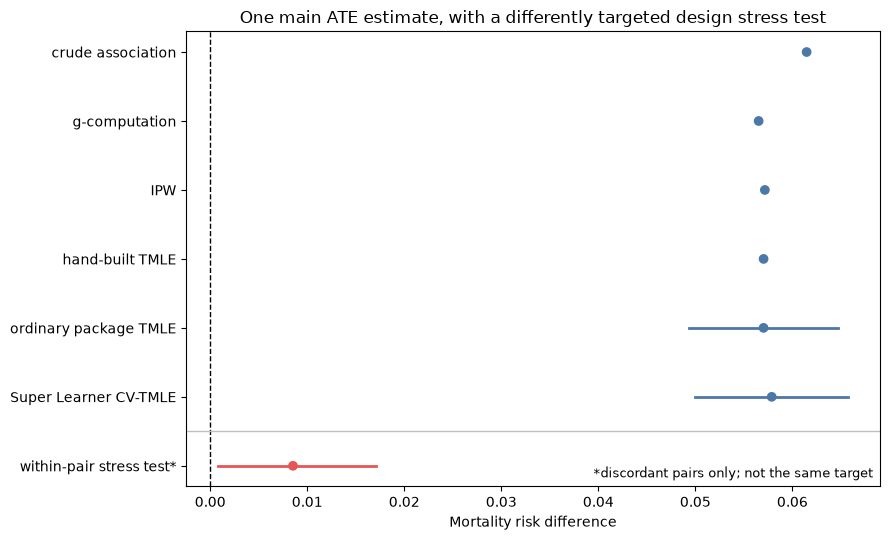

In [7]:
main_estimate = flexible_result["ate"]
comparison = pd.DataFrame(
    [
        {"method": "crude association", "estimate": crude_rd},
        {"method": "g-computation", "estimate": gcomp_ate},
        {"method": "IPW", "estimate": ipw_ate},
        {"method": "hand-built TMLE", "estimate": manual_tmle_ate},
        {
            "method": "ordinary package TMLE",
            "estimate": ordinary_estimate.psi,
            "ci_low": ordinary_estimate.ci[0],
            "ci_high": ordinary_estimate.ci[1],
        },
        {
            "method": "Super Learner CV-TMLE",
            "estimate": main_estimate.psi,
            "ci_low": main_estimate.ci[0],
            "ci_high": main_estimate.ci[1],
        },
        {
            "method": "within-pair stress test*",
            "estimate": paired_rd,
            "ci_low": paired_ci[0],
            "ci_high": paired_ci[1],
        },
    ]
)
assert (
    comparison.loc[comparison["method"] == "ordinary package TMLE", ["ci_low", "ci_high"]]
    .notna()
    .all(axis=None)
)

fig, ax = plt.subplots(figsize=(9, 5.5))
y = np.arange(len(comparison))
colors = ["#4c78a8"] * 6 + ["#e45756"]
ax.scatter(comparison["estimate"], y, color=colors, zorder=3)
for index, row in comparison.dropna(subset=["ci_low"]).iterrows():
    ax.plot([row.ci_low, row.ci_high], [index, index], color=colors[index], linewidth=2)
ax.axvline(0, color="black", linewidth=1, linestyle="--")
ax.axhline(5.5, color="0.75", linewidth=1)
ax.set_yticks(y, comparison["method"])
ax.set_xlabel("Mortality risk difference")
ax.set_title("One main ATE estimate, with a differently targeted design stress test")
ax.text(
    0.99,
    0.02,
    "*discordant pairs only; not the same target",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
)
ax.invert_yaxis()
fig.tight_layout()
comparison

The hand calculation and ordinary package TMLE agree because they use the same learners, rows, and one pooled fluctuation. The ordinary package interval is now shown because the package fit computes it; the hand calculation remains point-only because we did not implement its cluster-robust influence-curve variance by hand. The production CV-TMLE is the inferential result to carry forward because its flexible nuisance fits are evaluated out of sample. The nearby point estimates and intervals show numerical stability under this adjustment strategy; they do not validate exchangeability or prove that one estimator is correct.

The figure intentionally does not ask whether confidence intervals from several estimators overlap. These estimates use the same observations and are highly correlated, so overlap is not a test of estimator equivalence.

## 7. Diagnose observable parts of the fit

Start with the combined diagnostic report. It records the checks that ran, retains their detailed reports, and names operations that were not requested or do not apply. It cannot detect an ill-defined intervention, a missing common cause, or a wrong causal graph.

In [8]:
point_diagnostics = flexible_result.diagnostics.run_all()
print(point_diagnostics.summary())
print()
print(point_diagnostics.report("nuisance_models").summary())
print()
print(point_diagnostics.report("score_equations").summary())

diagnostic        status          detail                                                                          next step                                                                          
----------------  --------------  ------------------------------------------------------------------------------  -----------------------------------------------------------------------------------
support           completed       maximum truncated fraction 0.0%; minimum effective-sample-size ratio 91.9%                                                                                         
nuisance_models   completed       2 nuisance model report(s) are available                                                                                                                           
score_equations   passed          2 score row(s); worst abs(score) / threshold = 1.41e-05                                                                                                            
correction

Positivity / overlap diagnostics
--------------------------------
n = 12000; propensity truncated to [0.004859, 0.9951]

g(W) quantile  0%      1%      5%      25%     50%     75%     95%     99%     100%  
-------------  ------  ------  ------  ------  ------  ------  ------  ------  ------
overall        0.2642  0.3372  0.3676  0.4244  0.4863  0.5938  0.7355  0.8110  0.9548
treated        0.2642  0.3415  0.3748  0.4387  0.5174  0.6272  0.7578  0.8299  0.9548
control        0.2817  0.3334  0.3627  0.4132  0.4622  0.5496  0.6993  0.7771  0.8969

arm      n     effective n  ESS / n  top 1% weight  top 5% weight
-------  ----  -----------  -------  -------------  -------------
treated  6174  5891.9       0.954    0.016          0.072        
control  5826  5353.7       0.919    0.026          0.097        

threshold  P(g < t)  P(g > 1-t)
---------  --------  ----------
0.01       0.0000    0.0000    
0.025      0.0000    0.0000    
0.05       0.0000    0.0001    
0.1        0.0000    0.

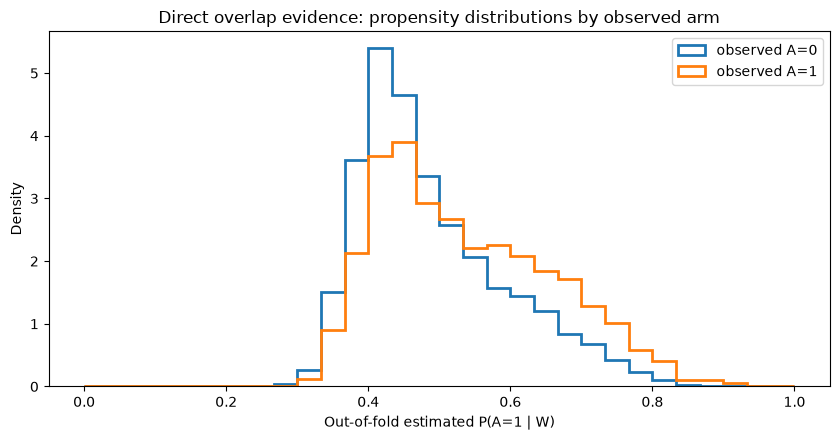

In [9]:
positivity = point_diagnostics.report("support")
g_hat = flexible_result.nuisance.propensity.arm(1.0)
print(positivity.summary())

fig, ax = plt.subplots(figsize=(8.5, 4.5))
bins = np.linspace(0, 1, 31)
ax.hist(g_hat[A == 0], bins=bins, density=True, histtype="step", linewidth=2, label="observed A=0")
ax.hist(g_hat[A == 1], bins=bins, density=True, histtype="step", linewidth=2, label="observed A=1")
ax.set_xlabel("Out-of-fold estimated P(A=1 | W)")
ax.set_ylabel("Density")
ax.set_title("Direct overlap evidence: propensity distributions by observed arm")
ax.legend()
fig.tight_layout()

The support row reads `completed` rather than `passed`. It grades the truncated fraction, which is zero here. It reports the effective sample size without grading it, because no cutoff on a Kish ratio is derived from anything.

That share is yours to judge. Here the propensity distributions overlap broadly, and arm-specific ESS stays close to the observed arm sizes. The propensity distributions overlap broadly, no rows were truncated, and arm-specific ESS remains close to the observed arm sizes.

Propensity AUC is a prediction metric, not a positivity test: a low AUC can coexist with a poorly fitted mechanism, while a high AUC can reflect strong but still nonzero assignment probabilities. Likewise, the maximum clever covariate is not a bound on total influence; influence also contains the outcome residual and plug-in term. The score near machine zero establishes numerical solution of the fitted equation only.

## 8. Put omitted-confounding sensitivity on a concrete scale

The omitted-variable bound describes how much residual outcome variation and treatment-side variation an unmeasured confounder could explain. It is a scenario analysis, not a detector. We show the worst-case alignment ρ=1 and benchmark the abstract scale against jointly removing two observed covariates.

In [10]:
sensitivity_report = flexible_result.sensitivity.run_all(
    include_refits=True,
    random_state=SEED,
    arguments={
        "omitted_confounding": {
            "estimand": "ate",
            "cf_y": 0.05,
            "cf_d": 0.05,
            "rho": 1.0,
        },
        "benchmark": {
            "covariates": ("preterm", "tobacco"),
            "estimand": "ate",
        },
    },
)
omitted = sensitivity_report.report("omitted_confounding")
benchmark = sensitivity_report.report("benchmark")
print(sensitivity_report.summary())
print()
print(omitted.summary())
print()
print(benchmark.summary())

diagnostic             status          detail                                                                                                                                                             next step
---------------------  --------------  -----------------------------------------------------------------------------------------------------------------------------------------------------------------  ---------
omitted_confounding    completed       cf_y=0.05, cf_d=0.05, rho=1; bias-adjusted interval [0.03844, 0.0773]                                                                                                       
robustness_value       completed       point robustness value 0.1415; confidence-limit value 0.1304                                                                                                                
elements               completed       sigma2=0.034, nu2=4.22, max_bias=0.3788                                                                          

The combined report records related calculations and explicit omissions. We retrieve the two reports that use the choices above.

The robustness value sets cf_y=cf_d and assumes worst-case alignment; it is a threshold, not the probability that confounding exists. The benchmark says how the fitted residual quantities change when `preterm` and `tobacco` are removed together. It does not prove that an omitted variable resembles those covariates.

The small movement from crude to adjusted estimates does not show that strong unmeasured confounding is unlikely. The within-pair stress test contradicts that argument.

## 9. Report absolute and relative scales without mixing uncertainty scales

A risk difference and risk ratio answer different reporting questions. We estimate the two counterfactual risks with the same CV-TMLE configuration, calculate their ratio as a point summary, and leave ratio-scale inference to the typed estimand API documented in the [estimands guide](../user-guide/estimands.md).

In [11]:
risk_result = point_study.estimate(CounterfactualMean(), method=flexible_method)
risk0 = risk_result["ey[0]"]
risk1 = risk_result["ey[1]"]
scale_table = pd.DataFrame(
    [
        {
            "quantity": "risk under A=0",
            "estimate": risk0.psi,
            "ci_low": risk0.ci[0],
            "ci_high": risk0.ci[1],
            "uncertainty": "risk scale",
        },
        {
            "quantity": "risk under A=1",
            "estimate": risk1.psi,
            "ci_low": risk1.ci[0],
            "ci_high": risk1.ci[1],
            "uncertainty": "risk scale",
        },
        {
            "quantity": "risk difference",
            "estimate": main_estimate.psi,
            "ci_low": main_estimate.ci[0],
            "ci_high": main_estimate.ci[1],
            "uncertainty": "difference scale",
        },
        {
            "quantity": "risk ratio (point summary)",
            "estimate": risk1.psi / risk0.psi,
            "ci_low": np.nan,
            "ci_high": np.nan,
            "uncertainty": "not shown; use typed RiskRatio fit",
        },
    ]
)
scale_table

,quantity,estimate,ci_low,ci_high,uncertainty
0,risk under A=0,0.0045,0.0023,0.0067,risk scale
1,risk under A=1,0.0624,0.0548,0.0699,risk scale
2,risk difference,0.0579,0.0500,0.0658,difference scale
3,risk ratio (point summary),13.9058,NaN,NaN,not shown; use typed RiskRatio fit


## 10. A semi-synthetic longitudinal extension with known truth

The source prenatal fields are end-of-pregnancy summaries; their metadata do not establish a valid sequence of measurements. Instead of inventing timestamps, this section keeps one real baseline row per sampled pair and generates clearly prefixed longitudinal nodes and a synthetic outcome. Nothing below is a finding about prenatal care or mortality.

```text
W ─────▶ A1 ─────▶ L2 ─────▶ A2 ─────▶ Y
│         │         │         │         ▲
└─────────┴─────────┴─────────┴─────────┘
```

L2 is affected by A1 and affects both A2 and Y, so it is a time-varying confounder for the second treatment. Because every conditional law is written down, the always-versus-never truth can be calculated exactly over the empirical baseline population.

In [12]:
sim_w1 = X["dmar"].fillna(0).to_numpy(float)
sim_w2 = np.maximum(
    X["diabetes"].fillna(0).to_numpy(float),
    X["chyper"].fillna(0).to_numpy(float),
)
sim_rng = np.random.default_rng(SEED + 1)

sim_p_a1 = expit(-0.2 + 0.8 * sim_w1 - 0.6 * sim_w2)
sim_a1 = sim_rng.binomial(1, sim_p_a1)
sim_p_l2 = expit(-0.7 + 0.9 * sim_a1 + 0.8 * sim_w2)
sim_l2 = sim_rng.binomial(1, sim_p_l2)
sim_p_a2 = expit(-0.3 + 0.5 * sim_a1 + sim_l2 + 0.4 * sim_w1)
sim_a2 = sim_rng.binomial(1, sim_p_a2)
sim_p_y = expit(-2.2 - 0.35 * sim_a1 - 0.55 * sim_a2 + 0.9 * sim_l2 + 0.5 * sim_w2)
sim_y = sim_rng.binomial(1, sim_p_y)

semi = pd.DataFrame(
    {
        "sim_W1": sim_w1,
        "sim_W2": sim_w2,
        "sim_A1": sim_a1,
        "sim_L2": sim_l2,
        "sim_A2": sim_a2,
        "sim_Y": sim_y,
    }
)


def exact_regime_risk(a1, a2):
    p_l2 = expit(-0.7 + 0.9 * a1 + 0.8 * sim_w2)
    q_l2_0 = expit(-2.2 - 0.35 * a1 - 0.55 * a2 + 0.5 * sim_w2)
    q_l2_1 = expit(-2.2 - 0.35 * a1 - 0.55 * a2 + 0.9 + 0.5 * sim_w2)
    return np.mean((1 - p_l2) * q_l2_0 + p_l2 * q_l2_1)


truth_always = exact_regime_risk(1, 1)
truth_never = exact_regime_risk(0, 0)
truth_contrast = truth_always - truth_never
assert np.isclose(truth_contrast, -0.06464265455218184)

pd.Series(
    {
        "P(sim_A1=1)": semi["sim_A1"].mean(),
        "P(sim_L2=1)": semi["sim_L2"].mean(),
        "P(sim_A2=1)": semi["sim_A2"].mean(),
        "P(sim_Y=1)": semi["sim_Y"].mean(),
        "exact risk: always": truth_always,
        "exact risk: never": truth_never,
        "exact always-minus-never truth": truth_contrast,
    },
    name="value",
)

P(sim_A1=1)                       0.5920
P(sim_L2=1)                       0.4685
P(sim_A2=1)                       0.6643
P(sim_Y=1)                        0.0955
exact risk: always                0.0759
exact risk: never                 0.1405
exact always-minus-never truth   -0.0646
Name: value, dtype: float64

Longitudinal TMLE (2 time points, n = 6000)

parameter                     estimate  std. error  95% CI              p-value
----------------------------  --------  ----------  ------------------  -------
ate_regimen[always vs never]  -0.0639   0.0128      [-0.0889, -0.0389]  <1e-4  

  time points: 2
  outcome family: binomial
  regimens: always=(1/1), never=(0/0)
  reference: never
  cross-fitting: 3 fold(s)
  g_bounds: fixed [0.01, 1] on each cumulative treatment-and-censoring probability (package default; R ltmle-compatible heuristic -- inspect truncation diagnostics)
  confidence level: 95%
  random_state: 2026
  causal estimand: contrast of each regime against the reference
  identification: explicit-adjustment; sequential g-formula under the declared treatment regimen
  identification assumptions: consistency: each observed history equals the potential history under its realized regimen; no interference: one unit's potential history does not depend on other units' regimens; sequ

,quantity,estimate,ci_low,ci_high
0,naive observed-regime contrast,-0.0443,NaN,NaN
1,LTMLE,-0.0639,-0.0889,-0.0389
2,exact empirical-population truth,-0.0646,NaN,NaN


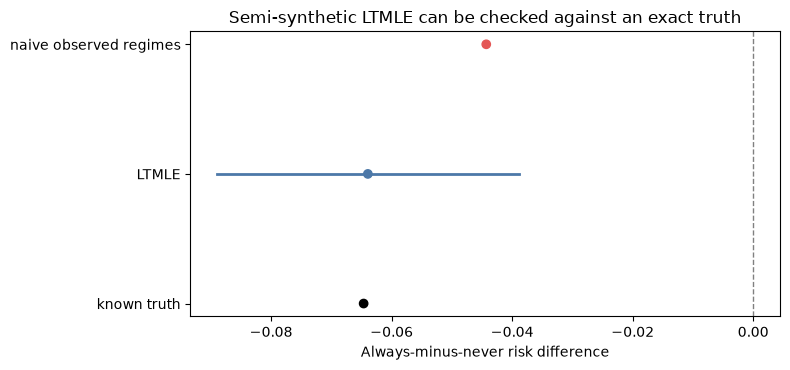

In [13]:
long_study = CausalStudy(
    semi,
    design=LongitudinalTreatment(
        outcome="sim_Y",
        treatment=("sim_A1", "sim_A2"),
        baseline=("sim_W1", "sim_W2"),
        time_varying=((), ("sim_L2",)),
        outcome_family="binomial",
    ),
)
regime_effect = long_study.identify(RegimeContrast({"always": 1, "never": 0}, reference="never"))
long_result = regime_effect.estimate(
    outcome_learner=LogisticRegression(max_iter=3_000),
    pseudo_learner=LinearRegression(),
    treatment_learner=LogisticRegression(max_iter=3_000),
    n_folds=3,
    learner_folds=3,
    simultaneous=False,
    random_state=SEED,
)
long_estimate = long_result["ate_regimen[always vs never]"]

observed_regime_risks = semi.groupby(["sim_A1", "sim_A2"])["sim_Y"].mean()
naive_longitudinal = observed_regime_risks.loc[(1, 1)] - observed_regime_risks.loc[(0, 0)]

long_diagnostics = long_result.diagnostics.run_all()
print(long_result.summary())
print()
print(long_diagnostics.summary())
print()
print(long_diagnostics.report("stagewise").to_frame())
print()
print(long_diagnostics.report("score_equations").to_frame())
print()
print(long_diagnostics.report("nuisance_models").to_frame())

fig, ax = plt.subplots(figsize=(8, 3.8))
labels = ["naive observed regimes", "LTMLE", "known truth"]
values = [naive_longitudinal, long_estimate.psi, truth_contrast]
ax.scatter(values, np.arange(3), color=["#e45756", "#4c78a8", "black"], zorder=3)
ax.plot(
    [long_estimate.ci[0], long_estimate.ci[1]],
    [1, 1],
    color="#4c78a8",
    linewidth=2,
)
ax.axvline(0, color="0.5", linestyle="--", linewidth=1)
ax.set_yticks(np.arange(3), labels)
ax.set_xlabel("Always-minus-never risk difference")
ax.set_title("Semi-synthetic LTMLE can be checked against an exact truth")
ax.invert_yaxis()
fig.tight_layout()

pd.DataFrame(
    [
        {"quantity": "naive observed-regime contrast", "estimate": naive_longitudinal},
        {
            "quantity": "LTMLE",
            "estimate": long_estimate.psi,
            "ci_low": long_estimate.ci[0],
            "ci_high": long_estimate.ci[1],
        },
        {"quantity": "exact empirical-population truth", "estimate": truth_contrast},
    ]
)

The exact contrast is about −0.0646, and the fixed-seed LTMLE estimate is close to it. The known data-generating process makes this agreement interpretable. Agreement in the real-data section cannot verify exchangeability.

The stagewise table shows how many rows follow each regime and the Kish ESS of the cumulative inverse-probability weights. ESS is a support diagnostic, not an input used to calculate the influence-curve standard error. Maximum weight is likewise not an observation's total influence.

The aggregate has two score rows per stage because this fit uses cross-fitting. Solver rows check the fitted equations. Stitching rows check pooled residuals against their sampling scale. The nuisance row covers sequential outcome regressions, not treatment models. The report also names longitudinal truncation curves and refutations as unavailable.

## 11. Takeaways

1. Identification is a scientific claim; an estimator cannot repair an incoherent intervention or missing common cause.
2. G-computation and IPW expose the two nuisance routes; targeting solves a parameter-specific empirical equation using both.
3. Cross-fitting and cluster-aware inference address estimation and dependence, not confounding.
4. Triage with the combined report, then plot the propensities, weights, or design contrasts that the flagged row names.
5. Use a known-truth semi-synthetic example when the real variables have no defensible time order.

In [14]:
pd.Series(
    {
        "python": platform.python_version(),
        "cleverly": cleverly.__version__,
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit-learn": sklearn.__version__,
        "CEVAE data commit": COMMIT,
        "seed": SEED,
        "sampled pairs": N_PAIRS,
    },
    name="value",
)

python                                                 3.13.7
cleverly                                                0.1.1
numpy                                                   2.4.6
pandas                                                  3.0.5
scikit-learn                                            1.9.0
CEVAE data commit    9081f863e24ce21bd34c8d6a41bf0edc7d1b65dd
seed                                                     2026
sampled pairs                                            6000
Name: value, dtype: object